# Показатели ВВП Ганы

Задача: Проанализировать показатели ВВП Республики Гана.

Данные представляют собой:
- year - год;
- GDP (current US Dollars) - ВВП (в долларах США). 

### Библиотеки для работы проекта:

In [78]:
import pandas as pd
import numpy as np
# Модули для визуализации автокорреляции и частичной автокорреляции (ACF/PACF)
import statsmodels.graphics.tsaplots as sgt
# Библиотека для автоматического подбора параметров ARIMA (Auto ARIMA)
import pmdarima as pm
# Импорт модели ARCH (Autoregressive Conditional Heteroskedasticity) — используется в финансовых рядах
from arch import arch_model
from sklearn.linear_model import LinearRegression
# TimeSeriesSplit — разбиение данных на тренировочные и тестовые части
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
# Тест Дики-Фуллера — проверка временного ряда на стационарность
from statsmodels.tsa.stattools import adfuller
# Метрика MSE
from sklearn.metrics import mean_squared_error
# Графики
from matplotlib import pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Первичное ознакомление с данными:

In [80]:
# Столбец 'year' используется как индекс временного ряда и сразу преобразуется в тип datetime.
ghana_gdp_df = pd.read_csv('Data/ghana_gdp.csv', index_col=['year'], parse_dates=['year'])
print(ghana_gdp_df.head(5))
#print(ghana_gdp_df[ghana_gdp_df['GDP (current US$)'] == 0])

            GDP (current US$)
year                         
1960-01-01       1.217087e+09
1961-01-01       0.000000e+00
1962-01-01       1.382353e+09
1963-01-01       1.540616e+09
1964-01-01       1.731092e+09


### Вывод:
При первичном ознакомлении с данными сразу бросается в глаза нулевое значение 0.0 в 1961 году, стоит сразу его заменить на интерполяционное значение, т.к. в данных всего один пропуск и можно смело применить этот способ. 

Примечание: Я закомментировал этот код, т.к. оказалось, что в следующем задании интерполяция и сэммплинг рассматривается в качестве заданий.

In [3]:
# ghana_gdp_df['GDP (current US$)'] = ghana_gdp_df['GDP (current US$)'].replace(0, np.nan)
# ghana_gdp_df['GDP (current US$)'] = ghana_gdp_df['GDP (current US$)'].interpolate()
# print(ghana_gdp_df.head(5))

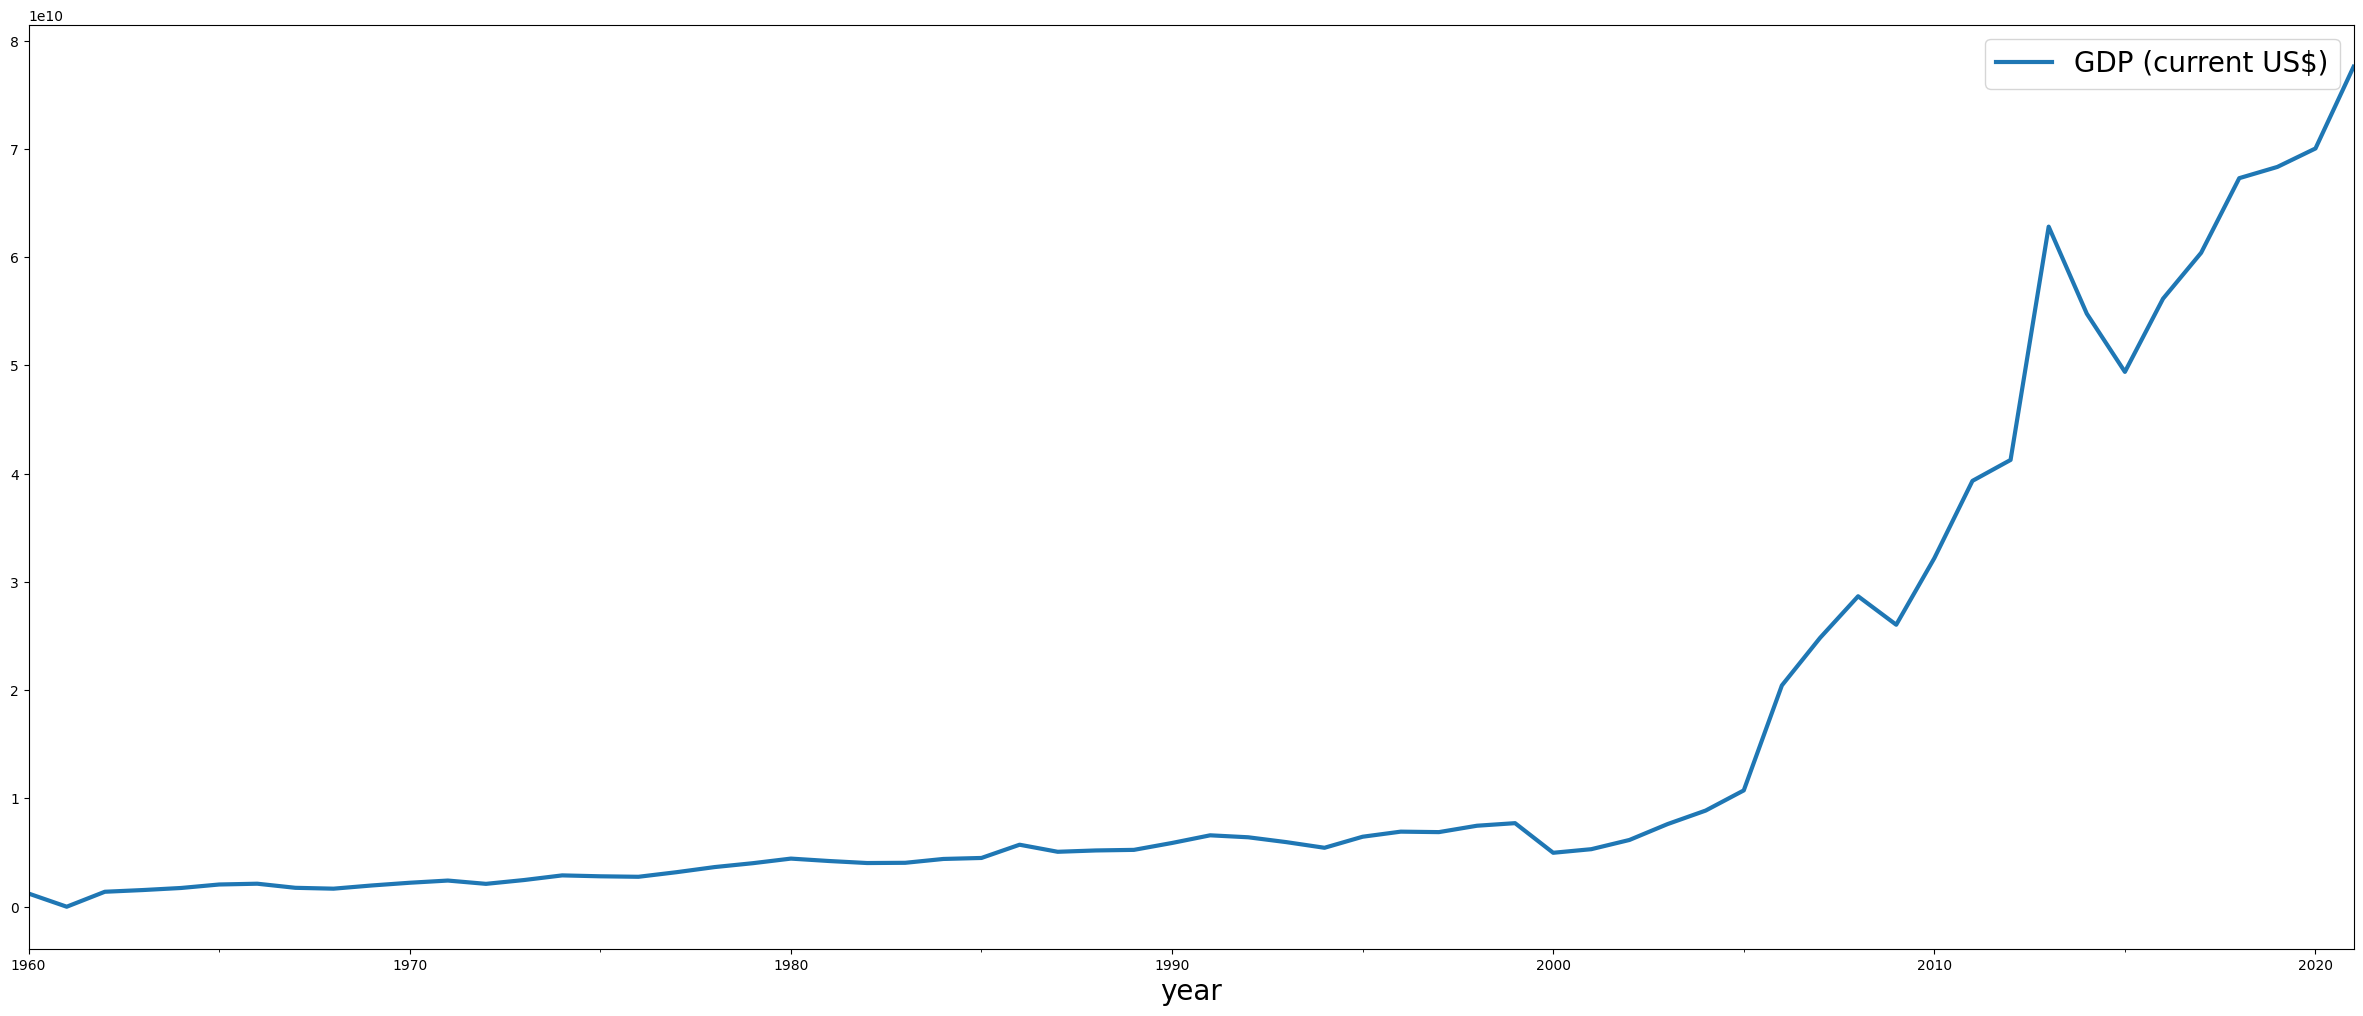

In [81]:
plt.rcParams["figure.figsize"] = 30, 12
plt.rcParams["font.size"] = 20
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["lines.linewidth"] = 3

ghana_gdp_df.plot()
plt.show()

### Визуализируем исходный временной ряд:

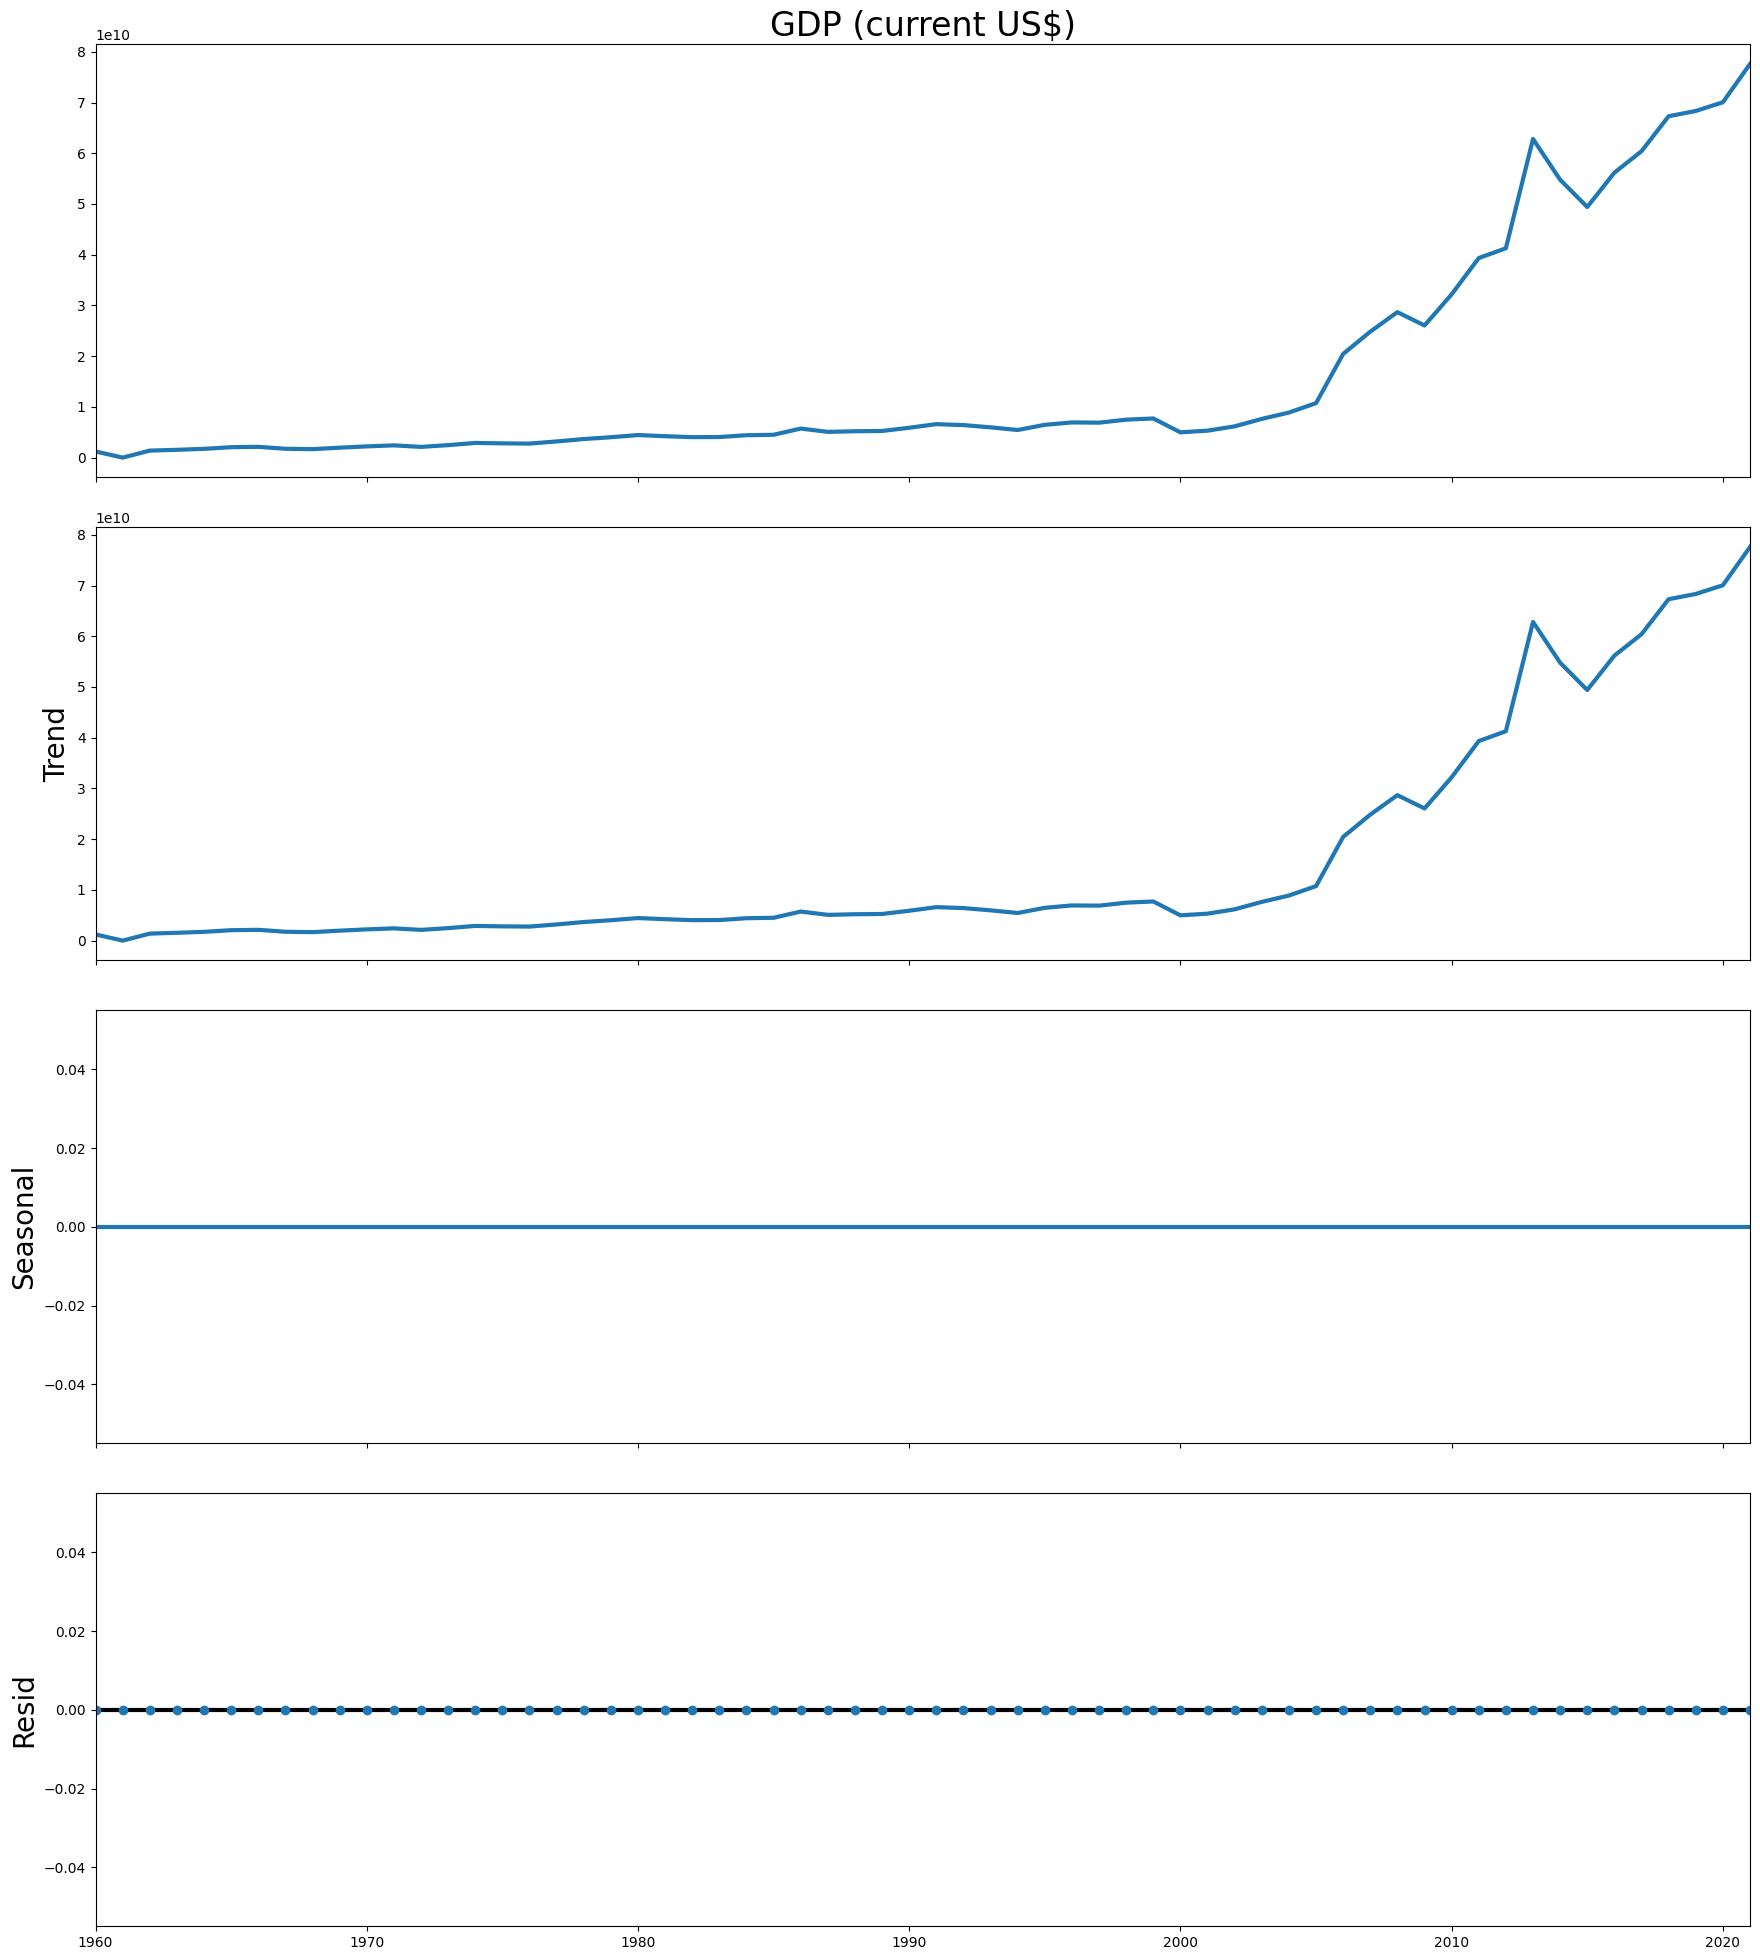

In [82]:
plt.rcParams["figure.figsize"] = 18, 20

# Декомпозиция
result = seasonal_decompose(ghana_gdp_df['GDP (current US$)'])
result.plot()
plt.show()

### Вывод:
В исходном ряду наблюдается резкий рост после 2000 года, до этого плавное движение с небольшими колебаниями. На графике видна выражанная восходящая динамика (рост ВВП).

В ряде явно присутствует тренд.

В компоненте trend почти точно наблюдается повторение графика с исходным рядом, нет резких скачков, но видно четкий рост примерно с 2007 года по 2008.

Сезонная компонента, линия абсолютно плоская, все значения примерно 0. Судя по всему метод не выявил сезонность в данных. Это скорее всего логично, т.к. данные годовые, т.е. одна точка в год.

Компонента остатков, остатки тоже близки к нулю. Нет выбросов, нет структуры — модель почти полностью объяснила поведение ряда трендом. Почти весь ряд описывается трендом, остатки — незначительны.

Ряд скорее всего является __нестационарным__ и требует дифференцирования для моделирования. Далее стоит проверить с помощью метода Дики-Фуллера.

### Отложим последние три года как тестовую выборку, для оценки результатов предсказания.

In [84]:
# Это будет использоваться для оценки качества прогноза
test_df = ghana_gdp_df.iloc[-3:]
# Остальные данные (все, кроме последних 3 лет) — в обучающую выборку.
train_df = ghana_gdp_df.iloc[:-3]
display(test_df)

,GDP (current US$)
year,
2019-01-01,6.833754e+10
2020-01-01,7.004320e+10
2021-01-01,7.759428e+10


Построим график скользящего среднего, проанализируем результат. Для построения MA используем метод rolling(), который принимает в качестве параметра размер окна. Используем среднее как функцию для сглаживания. 
Визуализируем исходный временной ряд и построенный с помощью скользящего среднего прогноз, сравним графики между собой и сделаем выводы.

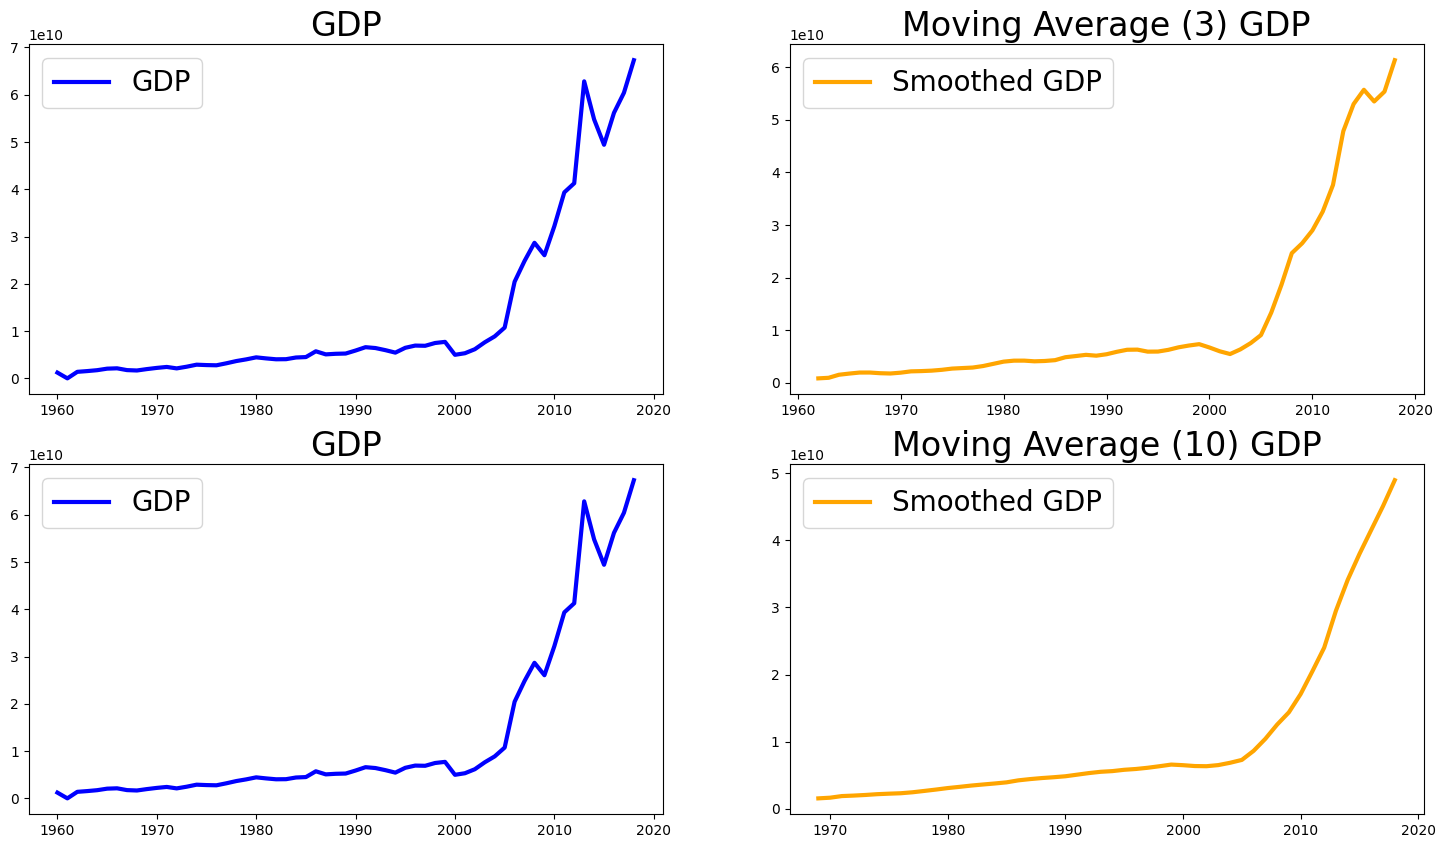

In [85]:
plt.rcParams["figure.figsize"] = 18, 10

fig, ax = plt.subplots(2, 2)

# Окно в месяц (Window = 30)
ax[0, 0].plot(train_df['GDP (current US$)'], color="blue", label="GDP")
ax[0, 0].set_title("GDP", size=24)
ax[0, 0].legend()

ax[0, 1].plot(
    train_df['GDP (current US$)'].rolling(window=3).mean(),
    color="orange",
    label="Smoothed GDP",
)

ax[0, 1].set_title("Moving Average (3) GDP", size=24)
ax[0, 1].legend()

# Окно в год (Window = 10)
ax[1, 0].plot(train_df['GDP (current US$)'], color="blue", label="GDP")
ax[1, 0].set_title("GDP", size=24)
ax[1, 0].legend()

ax[1, 1].plot(
    train_df['GDP (current US$)'].rolling(window=10).mean(),
    color="orange",
    label="Smoothed GDP",
)

ax[1, 1].set_title("Moving Average (10) GDP", size=24)
ax[1, 1].legend()

plt.show()

### Вывод:
Были выбраны два окна в 3 года и 10 лет.

Применение скользящего среднего с разной шириной окна показало, что ряд GDP содержит сильный восходящий тренд, особенно после 2000 года.
* MA(3) даёт более точное повторение формы исходного ряда, 
* MA(10) — более плавный тренд без локальных скачков.

Скользящее среднее в данном случае оказалось полезным как визуальный инструмент и может использоваться как базовая модель или для предобработки перед построением прогнозных моделей.

С помощью теста Дики-Фуллера оценим стационарность (скорее всего нестационарные данные, судя по графикам выше) временного ряда и примим решение о выборе модели ARMA/ARIMA.

In [86]:
adf_result = adfuller(train_df['GDP (current US$)'])
print("ADF= ", adf_result[0])
print("p-value= ", adf_result[1])
print("Critical values: ", adf_result[4])

if adf_result[0] > adf_result[4]["5%"]:
    print("ряд нестационарен")
else:
    print("ряд стационарен")

ADF=  0.6529066974885368
p-value=  0.9888496277665573
Critical values:  {'1%': np.float64(-3.5745892596209488), '5%': np.float64(-2.9239543084490744), '10%': np.float64(-2.6000391840277777)}
ряд нестационарен


### Вывод:

Ряд является ожидаемо нестационарным, дифференцируем его до тех пор, пока он не станет стационарным. Количество дифференцирований, необходимых для сведения ряда к стационарному, будем использовать в качестве параметра d для модели ARIMA.

In [87]:
# Решил сделать дифференциацию в цикле
series = train_df['GDP (current US$)']
d = 0

while True:
    adf_result = adfuller(series.dropna())
    print(f'd={d}, ADF={adf_result[0]}, p-value={adf_result[1]}')
    
    if adf_result[1] < 0.05:
        print(f'Ряд стал стационарным при d = {d}')
        stationary_series = series.dropna()
        break
    else:
        series = series.diff()
        d += 1

d=0, ADF=0.6529066974885368, p-value=0.9888496277665573
d=1, ADF=-1.6702483038320748, p-value=0.4465029329713906
d=2, ADF=-2.640869056128492, p-value=0.08484116917837631
d=3, ADF=-4.779623784828548, p-value=5.948327640224507e-05
Ряд стал стационарным при d = 3


Параметры p и q выберим по коррелограммам ACF и PACF.

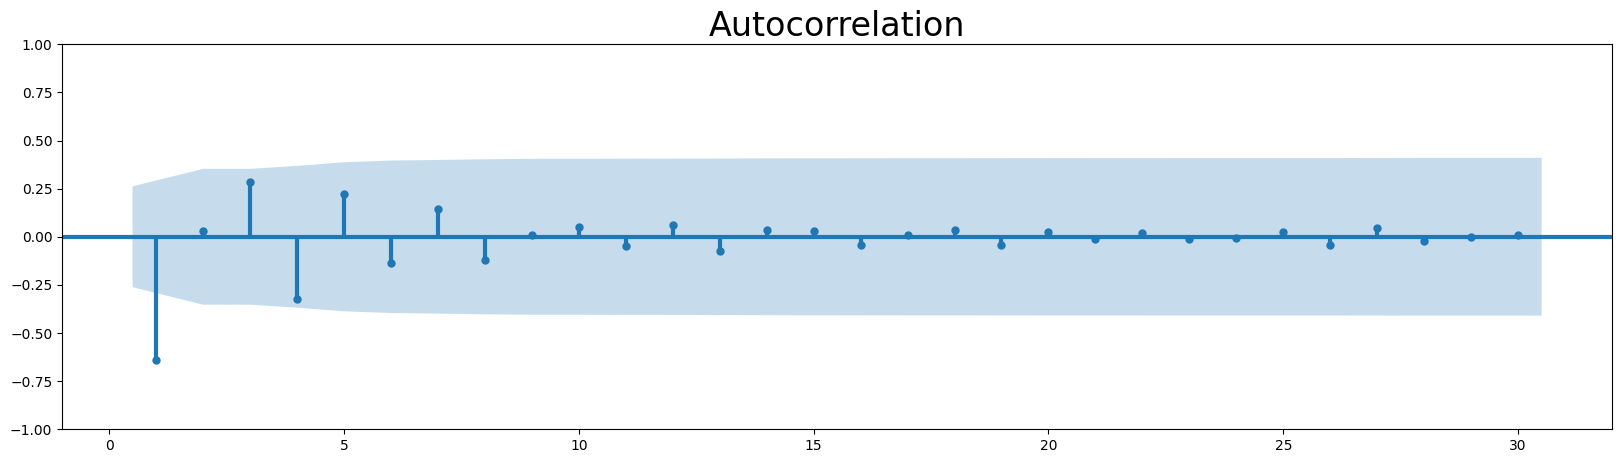

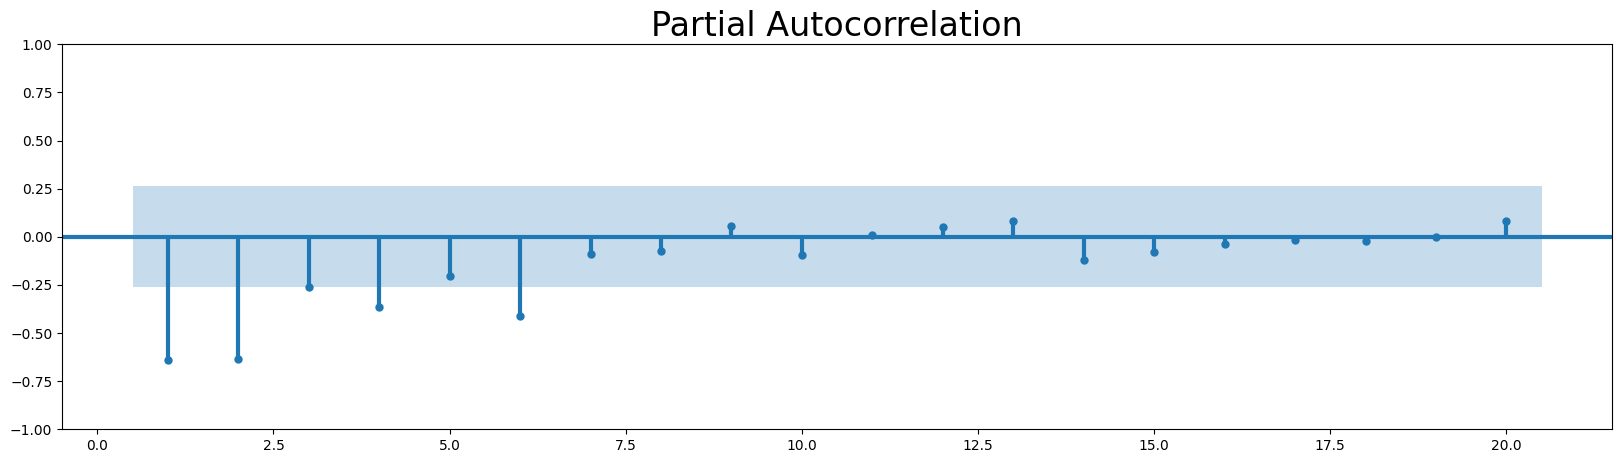

In [90]:
# ACF
plt.rcParams["figure.figsize"] = 20, 5
sgt.plot_acf(stationary_series, lags=30, zero=False)
plt.show()

# PACF
plt.rcParams["figure.figsize"] = 20, 5
sgt.plot_pacf(stationary_series, lags=20, zero=False)
plt.show()

### Вывод:

По ACF для q:

ACF обрывается после 3, выбираем q = 3.

Можно дополнительно протестировать q = 1 и q = 2 в альтернативных моделях, но q = 3 является скорее всего лучшим вариантом.

По PACF для p:

PACF резко обрывается после лага 4, выбираем p = 4.

In [91]:
# Как результат:
p, d, q = (3, 3, 4)

Теперь построим модель ARIMA для прогнозирования поведения временного ряда.

Также построим несколько моделей с параметрами, ближайшими к найденным p и q, и сравним коэффициент AIC и подберем наилучшие параметры с помощью пакета pmdarima.

In [92]:
arima_model = ARIMA(train_df['GDP (current US$)'].dropna(), order=(p, d, q))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(3, 3, 4)   Log Likelihood               -1318.388
Date:                Mon, 23 Jun 2025   AIC                           2652.777
Time:                        12:40:42   BIC                           2668.980
Sample:                    01-01-1960   HQIC                          2659.059
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7765      0.784     -2.267      0.023      -3.312      -0.241
ar.L2         -1.0132      1.139     -0.889      0.374      -3.246       1.219
ar.L3         -0.0794      0.632     -0.126      0.900      -1.318       1.160
ma.L1          0.0117      0.757      0.015      0.988      -1.473       1.496
ma.L2         -1.6434      0.439     -3.742      0.000      -2.504      -0.783
ma.L3         -0.0417      0.894     -0.047      0.963      -1.793       1.710
ma.L4          0.7399      0.567      1.305      0.192      -0.371       1.851
sigma2      2.707e+19   4.77e-20   5.68e+38      0.000    2.71e+19    2.71e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                84.63
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):             100.69   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.11e+56. Standard errors may be unstable.
"""

In [93]:
# Модели с другими параметрами
model_321 = ARIMA(train_df['GDP (current US$)'], order=(3,2,1)).fit()
model_221 = ARIMA(train_df['GDP (current US$)'], order=(2,2,1)).fit()

print("ARIMA(3,3,4):", arima_model_fit.aic)
print("ARIMA(3,2,1):", model_321.aic)
print("ARIMA(2,2,1):", model_221.aic)

ARIMA(3,3,4): 2652.7769561908644
ARIMA(3,2,1): 2685.7277649684183
ARIMA(2,2,1): 2683.7817994292245


/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/s

### Вывод:
Модель ARIMA(4,3,3) — наиболее подходящая модель по AIC, несмотря на сложность ее параметр AIC ниже других остальных. Стоит попробовать провести автоматизированный подбор параметров для сравнения с нашей моделью.

In [94]:
# Обучаем автоматическую ARIMA-модель
smodel = pm.auto_arima(
    train_df['GDP (current US$)'],  # Одномерный временной ряд (Series)

    # --- Параметры авторегрессии ---
    start_p=1,     # Начальное значение для p (AR — авторегрессия)
    start_q=1,     # Начальное значение для q (MA — скользящее среднее)
    max_p=5,       # Максимум для p — попробуем от 1 до 5
    max_q=5,       # Максимум для q — от 1 до 5

    # --- Порядок интегрирования ---
    d=None,        # Пусть определит порядок d автоматически на основе теста
    test='adf',    # Для оценки d используем ADF-тест на стационарность

    # --- Сезонность ---
    seasonal=False,  # Отключаем сезонную составляющую (у нас ее нет, годовые данные)
    # Если бы были месячные данные — здесь было бы True + seasonal_order

    # --- Стратегия подбора ---
    stepwise=False,  # Используем перебора всех вариантов (вместо быстрой жадной стратегии перебора моделей)

    # --- Обработка ошибок и лог ---
    error_action='ignore',     # Не прерывать при ошибках моделей
    suppress_warnings=True,    # Не показывать предупреждения
    trace=True                 # Показывать лог процесса подбора (что пробует, какие AIC)
)

# Печатаем сводку по лучшей найденной модели
print(smodel.summary())

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2728.025, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2730.117, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2732.547, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=2729.837, Time=0.04 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=2731.599, Time=0.07 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=2723.534, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2729.982, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2732.043, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2729.161, Time=0.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2724.973, Time=0.09 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=2731.128, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2731.990, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2734.012, Time=0.03 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2730.206, Time=0.11 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2723.992, Time=0.14 sec
 ARIMA(3,1

### Вывод:

Интересно, что автоматическая модель оказалась хуже, что то, что мы выбрали в качестве лучшей модели ARIMA(3,3,4). В данном случае, ручной подбор с предварительным анализом (ADF, ACF, PACF) сработал лучше, чем даже полный перебор.

Построим модель с наилучшими параметрами и выполнии предсказание для отложенной тестовой выборки (последние три года).

In [95]:
# Устанавливаем частоту временного ряда, чтобы не вылезали предупреждения
train_df.index.freq = 'YS'

arima_best = ARIMA(train_df['GDP (current US$)'].dropna(), order=(3, 3, 4))
arima_best_fit = arima_best.fit()

# Прогноз на 3 шага вперёд (предсказание на 3 года)
forecast_steps = 3

arima_best_pred = arima_best_fit.forecast(steps=forecast_steps)
print(arima_best_pred)

2019-01-01    6.596085e+10
2020-01-01    7.591020e+10
2021-01-01    7.721670e+10
Freq: YS-JAN, Name: predicted_mean, dtype: float64


/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


### Вывод: 

На выходе мы получили корректный прогноз в котором с каждым годом наблюдается увеличение ВВП, что соответствует общему тренду на рост.

Далее отобразим результат графически — построим графики истинного и предсказанного поведения временного ряда, а также 95%-ый доверительный интервал для прогноза.

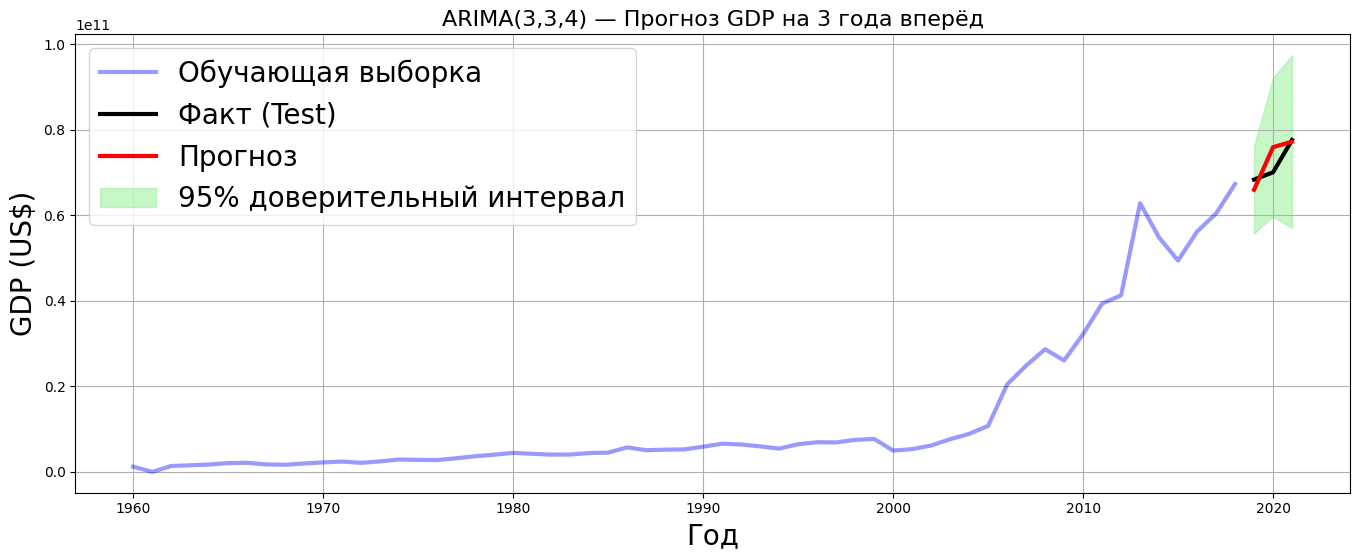

In [96]:
# Получаем прогноз и доверительный интервал на 3 года вперёд
forecast_result = arima_best_fit.get_forecast(steps=3)
forecast_values = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

# Объединяем с тестовой выборкой
pred_df = pd.DataFrame({
    "Actual": test_df['GDP (current US$)'],  # факт
    "Forecast": forecast_values,
    "Lower CI": conf_int.iloc[:, 0],
    "Upper CI": conf_int.iloc[:, 1]
})

# Рисуем
plt.figure(figsize=(14, 6))
plt.plot(train_df['GDP (current US$)'], label="Обучающая выборка", color="blue", alpha=0.4)
plt.plot(pred_df["Actual"], label="Факт (Test)", color="black")
plt.plot(pred_df["Forecast"], label="Прогноз", color="red")
plt.fill_between(pred_df.index, pred_df["Lower CI"], pred_df["Upper CI"],
                 color="lightgreen", alpha=0.5, label="95% доверительный интервал")

plt.title("ARIMA(3,3,4) — Прогноз GDP на 3 года вперёд", fontsize=16)
plt.xlabel("Год")
plt.ylabel("GDP (US$)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Вывод:

Модель ARIMA(3,3,4), построенная на исторических данных GDP Ганы, продемонстрировала высокую точность прогноза. Все три отложенных значения (2019–2021) попали в 95%-й доверительный интервал модели. Это подтверждает, что модель адекватно описывает динамику ряда и может использоваться для краткосрочного прогнозирования.

Проверим данные на наличие пропущенных дат. Помимо визуального способа, сделаем это с помощью метода DataFrame.asfreq(), передав в него параметр частоты, например ‘d’ — день, ‘m’ — месяц. В нашем случае год. 

In [97]:
# "YS" - Year Start, т.е. 1 января каждого года, как в наших данных
# "Y" - конец года т.е 31 декабря каждого года.
display(ghana_gdp_df.asfreq('YS')) # или "AS" - Annual Start

,GDP (current US$)
year,
1960-01-01,1.217087e+09
1961-01-01,0.000000e+00
1962-01-01,1.382353e+09
1963-01-01,1.540616e+09
1964-01-01,1.731092e+09
...,...
2017-01-01,6.040638e+10
2018-01-01,6.729928e+10
2019-01-01,6.833754e+10


Проверим данные на наличие пропущенных значений (Series.isna().sum()).

In [98]:
display(ghana_gdp_df.isna().sum())

GDP (current US$)    0
dtype: int64

In [99]:
# Дополнительно проверим есть ли пропущенные годы во временном ряду
display(ghana_gdp_df.asfreq('AS').isna().sum())

GDP (current US$)    0
dtype: int64

# Вывод:

В наших данных, ожидаемо есть значение 0.0. Код выше показал, что пропущенных значений действительно нет т.к. 0.0 не считается NaN. Годы тоже не пропущены во временном ряду, что хорошо.

Теперь сделаем проверку на наличие нулевых значений и в случае нахождения заменим их на NaN (по заданию).

In [100]:
ghana_gdp_df['GDP (current US$)'] = ghana_gdp_df['GDP (current US$)'].apply(lambda x: np.nan if x == 0 else x)
display(ghana_gdp_df.isna().sum())

GDP (current US$)    1
dtype: int64

Для заполнения пропусков выполним интерполяцию с использованием метода .interpolate().

In [101]:
ghana_gdp_df['GDP (current US$)'] = ghana_gdp_df['GDP (current US$)'].interpolate(method='linear')
print(ghana_gdp_df.head(5))

            GDP (current US$)
year                         
1960-01-01       1.217087e+09
1961-01-01       1.299720e+09
1962-01-01       1.382353e+09
1963-01-01       1.540616e+09
1964-01-01       1.731092e+09


Проверим полученный ряд на стационарность, определим параметры модели ARIMA и запустим модель.

In [102]:
def plot_acf_pacf(series):
    plt.rcParams["figure.figsize"] = 18, 5

    fig, axes = plt.subplots(1, 2)

    sgt.plot_acf(series, ax=axes[0], lags=30)
    sgt.plot_pacf(series, ax=axes[1], lags=20, method="ywm")
    plt.show()

ADF=  2.380848757555631
p-value=  0.99900101016983
Critical values:  {'1%': np.float64(-3.542412746661615), '5%': np.float64(-2.910236235808284), '10%': np.float64(-2.5927445767266866)}
ряд нестационарен
------------------------------------------------------------
d=0, ADF=2.380848757555631, p-value=0.99900101016983
d=1, ADF=-1.7397184892921487, p-value=0.4107731690667765
d=2, ADF=-1.7042548913503928, p-value=0.428921573011776
d=3, ADF=-5.456208629828454, p-value=2.578324497204243e-06
Ряд стал стационарным при d = 3
------------------------------------------------------------


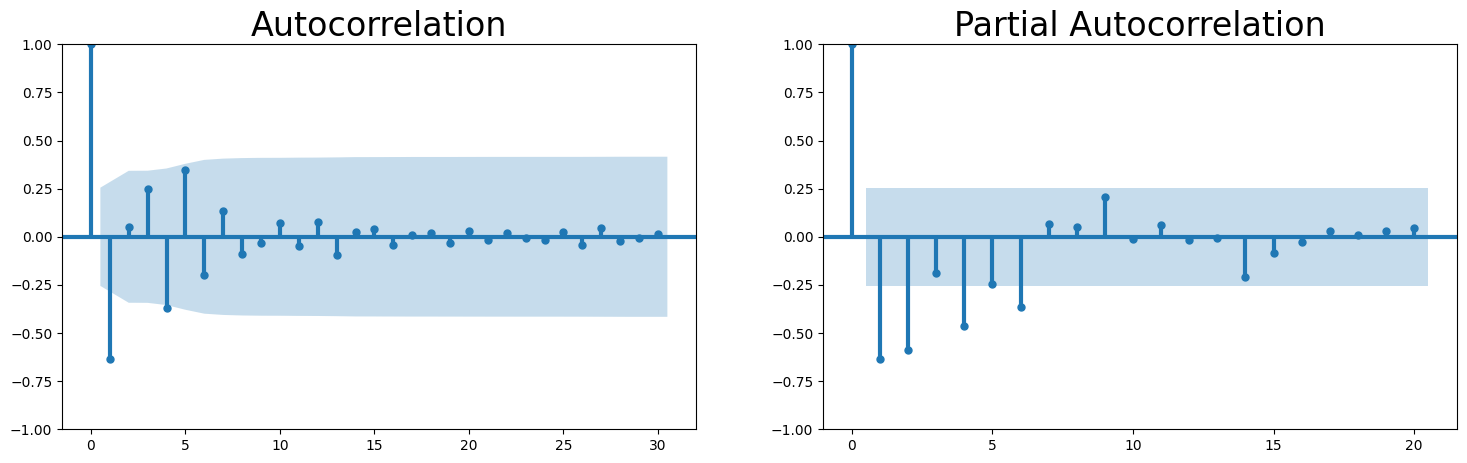

/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(2, 3, 5)   Log Likelihood               -1319.402
Date:                Mon, 23 Jun 2025   AIC                           2654.803
Time:                        12:41:40   BIC                           2671.006
Sample:                    01-01-1960   HQIC                          2661.085
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6358      0.393     -4.160      0.000      -2.406      -0.865
ar.L2         -0.8029      0.323     -2.486      0.013      -1.436      -0.170
ma.L1         -0.1965      0.507     -0.387      0.699      -1.191       0.798
ma.L2         -1.6105      0.564     -2.853      0.004      -2.717      -0.504
ma.L3          0.3250      0.767      0.424      0.672      -1.179       1.829
ma.L4          0.7097      0.625      1.136      0.256      -0.515       1.935
ma.L5         -0.1734      0.509     -0.341      0.733      -1.170       0.823
sigma2      2.895e+19   3.55e-20   8.16e+38      0.000    2.89e+19    2.89e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                83.08
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):             394.80   Skew:                            -0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.83e+54. Standard errors may be unstable.
"""

In [103]:
# 1. Проверка с помощью Дики-Фуллера
adf_result = adfuller(ghana_gdp_df['GDP (current US$)'])
print("ADF= ", adf_result[0])
print("p-value= ", adf_result[1])
print("Critical values: ", adf_result[4])

if adf_result[0] > adf_result[4]["5%"]:
    print("ряд нестационарен")
else:
    print("ряд стационарен")

print('-' * 60)

# 2. Дифференция
series = ghana_gdp_df['GDP (current US$)']
d = 0

while True:
    adf_result = adfuller(series.dropna())
    print(f'd={d}, ADF={adf_result[0]}, p-value={adf_result[1]}')
    
    if adf_result[1] < 0.05:
        print(f'Ряд стал стационарным при d = {d}')
        stationary_series = series.dropna()
        break
    else:
        series = series.diff()
        d += 1
        
print('-' * 60)

plot_acf_pacf(stationary_series)

# 3. Параметры для модели ARIMA
p, d, q = (2, 3, 5)

# 4. Разбиваем снова выборку
test_df = ghana_gdp_df.iloc[-3:]
train_df = ghana_gdp_df.iloc[:-3]
test_df

# 5. Модель ARIMA
arima_model = ARIMA(train_df['GDP (current US$)'].dropna(), order=(p, d, q))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

# Вывод:

После интерполяции одного пропущенного значения в временном ряду GDP Ганы была повторно проведена проверка на стационарность с помощью теста Дики-Фуллера. Результаты показали, что, как и в исходных данных, ряд становится стационарным только после трёхкратного дифференцирования (d = 3). На основании обновлённых графиков автокорреляции (ACF) и частичной автокорреляции (PACF) были выбраны параметры модели ARIMA(p=2, d=3, q=5).

Обученная модель ARIMA(2,3,5) продемонстрировала адекватное поведение и логичный прогноз, однако ее AIC оказался немного хуже по сравнению с моделью, построенной до интерполяции (AIC = 2654.80 против = 2652.77 у ARIMA(3,3,4)).

Таким образом, интерполяция одного значения не оказала существенного негативного влияния на модель, но и не улучшила ее. Полученная модель по-прежнему остаётся пригодной для краткосрочного прогнозирования.

### Разбиени временного ряда

Разбобьем временной ряд на три набора (3 train + 3 test). Для этого воспользуемся классом TimeSeriesSplit из sklearn.model_selection с параметрами n_splits=3 и test_size=7 (или max_train_size=df.sales.count()-7).

In [104]:
# Параметры: 3 разбиения, каждое тестовое — 7 лет
tscv = TimeSeriesSplit(n_splits=3, test_size=7)

Выведем размеры полученных подвыборок

In [105]:
train_test_groups = tscv.split(ghana_gdp_df['GDP (current US$)'])
for train_index, test_index in train_test_groups:
    print("TRAIN size:", len(train_index), "TEST size:", len(test_index))

TRAIN size: 41 TEST size: 7
TRAIN size: 48 TEST size: 7
TRAIN size: 55 TEST size: 7


# Вывод:

Проведя манипуляции по разбиению нашего временного ряда, на 3 фолда в котором каждое тестовое составляет 7 лет. В итоге мы получили множественное разбиение, т.к. TRAIN size c каждым разбиением увеличивается, а TEST выборка остается одинаковым по размеру.

Посчитаем волатильность для нашего временного ряда.

year
1960-01-01          NaN
1961-01-01     6.789413
1962-01-01     6.357759
1963-01-01    11.448835
1964-01-01    12.363636
Name: gdp_vol, dtype: float64

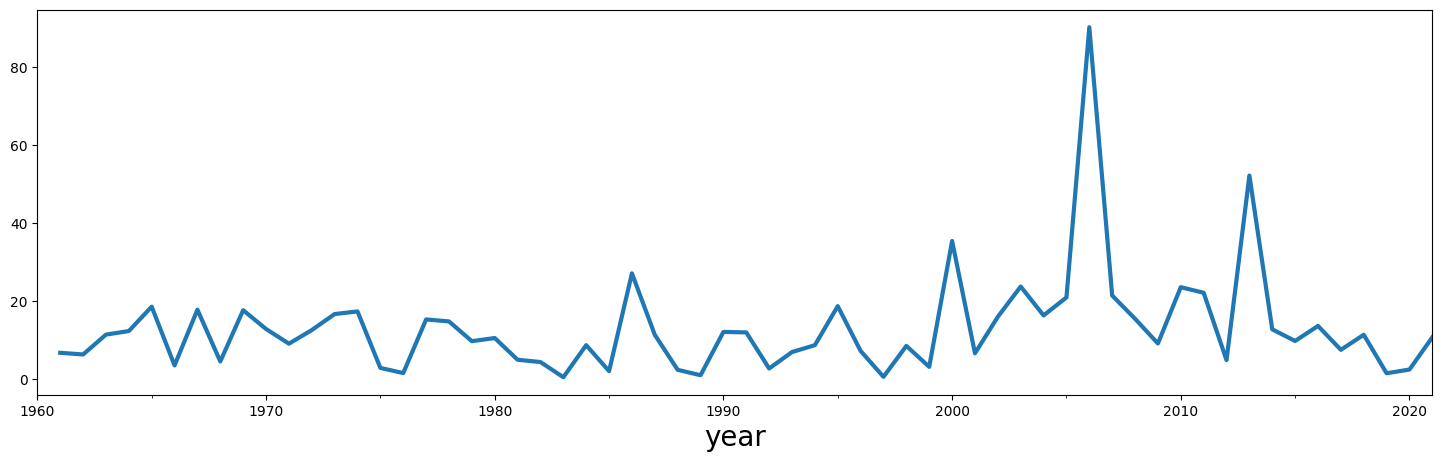

In [107]:
# Вычисляем процентное изменение (темп прироста) ВВП по сравнению с предыдущим годом
ghana_gdp_df["gdp_vol"] = ghana_gdp_df['GDP (current US$)'].pct_change(1).mul(100).abs()
display(ghana_gdp_df["gdp_vol"].head())

ghana_gdp_df["gdp_vol"].plot()
plt.show()

# Вывод:

Наибольшая волатильность послеживается в районе 2002–2003 гг. (возможно, был экономический скачок или кризис)

В примерно 2000 и 2015 г. также были резкие скачки волатильность ВВП в Гане нестабильна. Между 1970–1990 гг. — волатильность более умеренная и равномерная. В последние годы 2020 г. — волатильность относительно спокойная.

Используем GARCH-модель для предсказания волатильности.

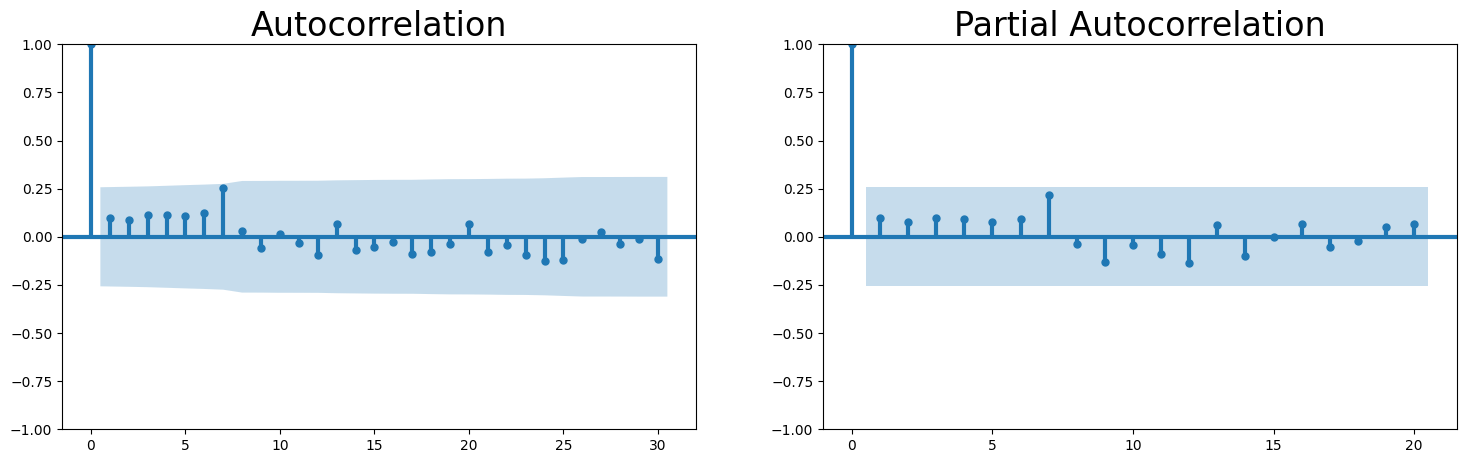

In [108]:
# Затем делим на train/test
test_df = ghana_gdp_df.iloc[-3:]
train_df = ghana_gdp_df.iloc[:-3]

plot_acf_pacf(train_df['gdp_vol'][1:])

In [109]:
# Думаю для начала, учитывая невыраженность лагов, можно начать с 1, 1
p, q = (1, 1)

In [110]:
# нам важно сохранить объем датасета, поэтому берем за исходные данные весь датасет с индексами, который содержит
# и train и test часть
garch_df = pd.DataFrame(ghana_gdp_df["gdp_vol"].loc[ghana_gdp_df.index])

# далее необходимо использовать актуальные обучающие данные, которые находятся в выборке train_df.
# Мы никак не преобразовывали нашу обучющую выборку, поэтому фактически, train_df совпадает с данными в data,
# Но если вы применяете к вашей обечающей выборке какие либо преобразования, например скользящее среднее
# для сглаживания, то необходимо передать измененный train_df датасет.
garch_df.loc[train_df.index, "gdp_vol"] = train_df["gdp_vol"].dropna()

Iteration:      5,   Func. Count:     27,   Neg. LLF: 251.18811047858395
Iteration:     10,   Func. Count:     57,   Neg. LLF: 4522.5403032525255
Iteration:     15,   Func. Count:     89,   Neg. LLF: 228.00251345130135
Iteration:     20,   Func. Count:    114,   Neg. LLF: 226.5978293605918
Optimization terminated successfully    (Exit mode 0)
            Current function value: 226.59781233106128
            Iterations: 22
            Function evaluations: 123
            Gradient evaluations: 22
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                gdp_vol   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -226.598
Distribution:                  Normal   AIC:                           461.196
Method:            Maximum Likelihood   BIC:                           469.437
                        

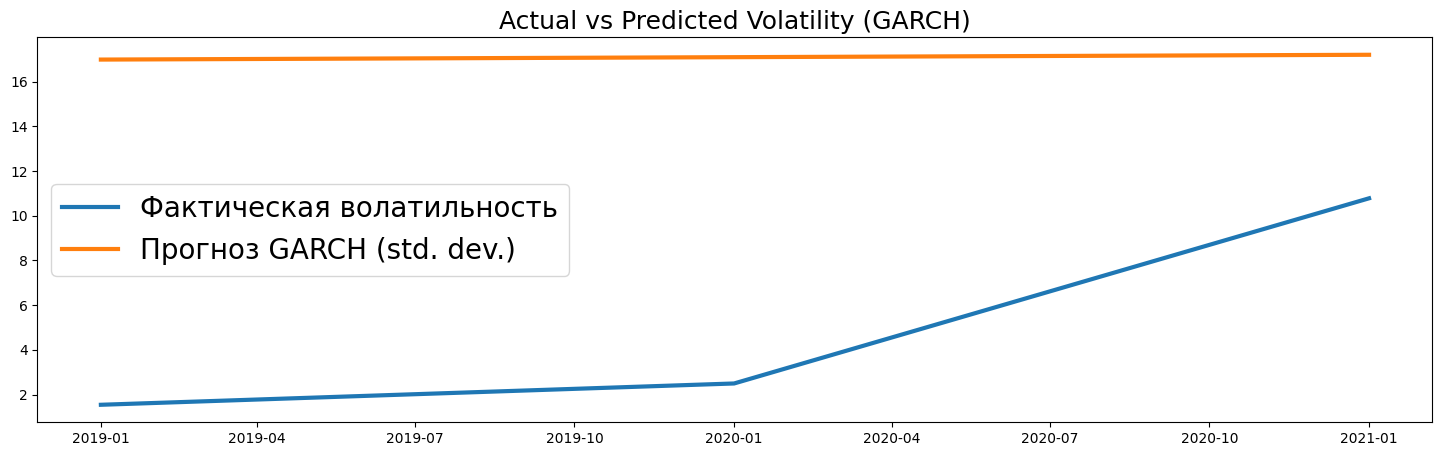

'MSE (GARCH) = 164.284'

In [111]:
garch = arch_model(garch_df["gdp_vol"].dropna(), p=p, q=q, vol='GARCH')

# в параметре last_obs указываем последний объект, до которого будем совершать обучение.
# в нашем случае это до первого объекта из test выборки
model_results = garch.fit(last_obs=test_df.index[0], update_freq=5)
print(model_results.summary())

predictions_df = test_df.copy()
predictions_df["Predictions"] = model_results.forecast().residual_variance.loc[
    test_df.index
]

plt.rcParams["figure.figsize"] = 18, 5

plt.plot(predictions_df["gdp_vol"], label="Фактическая волатильность")
plt.plot(np.sqrt(predictions_df["Predictions"]), label="Прогноз GARCH (std. dev.)")

plt.title("Actual vs Predicted Volatility (GARCH)", size=18)
plt.legend()
plt.show()

garch_preds = np.sqrt(model_results.forecast().residual_variance.loc[test_df.index])
mse = mean_squared_error(predictions_df["gdp_vol"].abs(), garch_preds)
display(f'MSE (GARCH) = {mse:.3f}')

Используем также линейную регрессию для получения прогноза

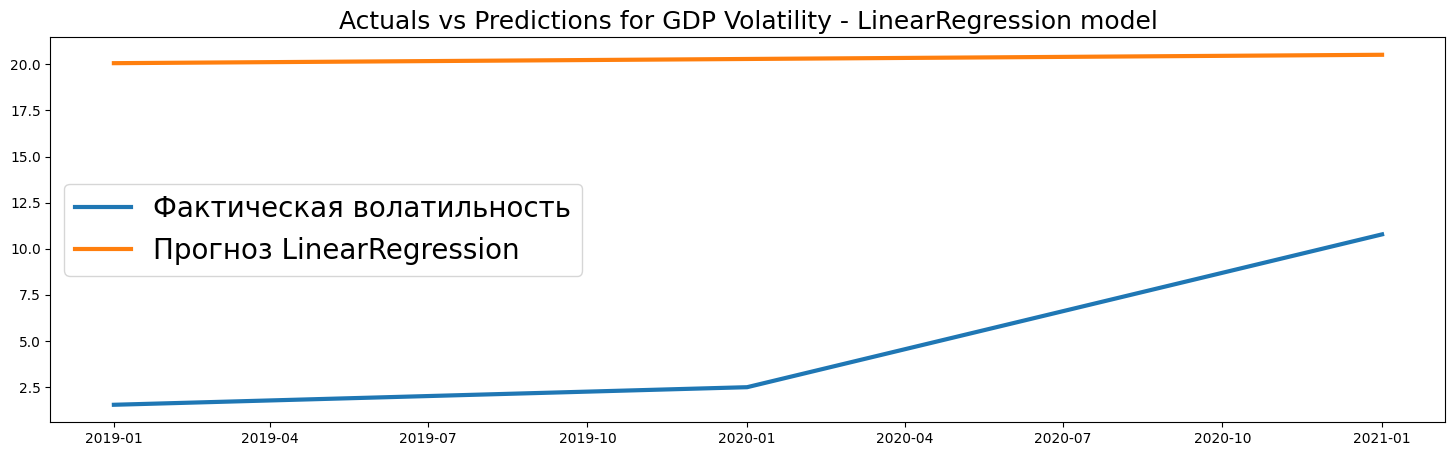

'MSE (LinearRegression) = 15.856'

In [112]:
X_train = pd.DataFrame(range(ghana_gdp_df["gdp_vol"].shape[0]))[
    : train_df.shape[0]
].fillna(0)

X_test = pd.DataFrame(range(ghana_gdp_df["gdp_vol"].shape[0]))[
    train_df.shape[0] :
].fillna(0)

y_train = train_df["gdp_vol"].fillna(0)
y_test = test_df["gdp_vol"].fillna(0)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predict = lr.predict(X_test)

plt.rcParams["figure.figsize"] = 18, 5

plt.plot(y_test, label="Фактическая волатильность")
plt.plot(pd.Series(lr_predict, index=y_test.index), label="Прогноз LinearRegression")

plt.title("Actuals vs Predictions for GDP Volatility - LinearRegression model", size=18)
plt.legend()
plt.show()

mse = np.sqrt(mean_squared_error(lr_predict, y_test))
display(f'MSE (LinearRegression) = {mse:.3f}')

# Вывод:

Результат модели GARCH получился именно таким  поскольку она предсказывает изменчивость (нестабильность), а не сами значения временного ряда. Модель учится по историческим колебаниям процентного изменения значений (в данном случае — gdp_vol). В наших данных волатильность относительно стабильная — с редкими всплесками. GARCH «подстраивается» под последние (ключевое) уровни дисперсии и предсказывает примерно постоянную волатильность, если в ближайшем прошлом не было «шока». В последних точеках перед test_df имеются плавные значения волатильности, поэтому GARCH спрогнозировала почти плоскую линию.

Так же GARCH-модели плохо предсказывают на малых данных, особенно при наличии одного-двух всплесков.

Таким образом модель не уловила дисперсию, так как такое поведение было для неё новым и подобные случаи отсутствовали в обучающей выборке.